In [1]:
setwd('/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb')
library(data.table)
library(ggplot2)
library(ggrepel)

In [3]:
d <- fread('data/saige/output/cts/step2_set/ukb_eur_wes_200k_annot_WHR_adj_BMI_pLoF_damaging_missense.txt')

In [4]:
head(d)

Region,Group,max_MAF,Pvalue,Pvalue_Burden,Pvalue_SKAT,BETA_Burden,SE_Burden,MAC,Number_rare,Number_ultra_rare
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>
ENSG00000187634,pLoF,0.001,0.3288721,0.9560969,0.2150682,0.0002133932,0.003876199,78,3,6
ENSG00000187634,pLoF,0.010,0.3288721,0.9560969,0.2150682,0.0002133932,0.003876199,78,3,6
ENSG00000187634,damaging_missense;pLoF,0.001,0.4199488,0.9593674,0.2831532,0.0001852556,0.003636207,92,3,9
ENSG00000187634,damaging_missense;pLoF,0.010,0.4199488,0.9593674,0.2831532,0.0001852556,0.003636207,92,3,9
ENSG00000187634,Cauchy,NA,0.3716603,0.9577950,0.2454216,NA,NA,NA,NA,NA
ENSG00000188976,pLoF,0.001,0.3716618,0.2365664,0.2550725,-0.0031101865,0.002627706,225,8,13


In [41]:

g <- "damaging_missense;pLoF"
s <- d[d$Group %in% g,]
s <- d[order(d$Pvalue_Burden),]
n <- nrow(s)
p.expt <- (1:n)/n

s$p.expt <- p.expt
threshold <- s$Pvalue_Burden < quantile(s$Pvalue_Burden, 0.05, na.rm = TRUE)
s$label <- NA
s$label[threshold] <- s$Region[threshold]


#s$label <- unlist(ifelse(s$Pvalue_burden < quantile(s$Pvalue_burden, 0.8), list(s$Region), NA)

In [43]:
head(s)

Region,Group,max_MAF,Pvalue,Pvalue_Burden,Pvalue_SKAT,BETA_Burden,SE_Burden,MAC,Number_rare,Number_ultra_rare,p.expt,label
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>,<chr>
ENSG00000123612,damaging_missense;pLoF,0.010,6.015941e-07,7.857169e-07,3.187940e-06,-0.006924772,0.0014020930,874,3,8,5.486366e-05,ENSG00000123612
ENSG00000123612,Cauchy,NA,2.406377e-06,3.142860e-06,1.275199e-05,NA,NA,NA,NA,NA,1.097273e-04,ENSG00000123612
ENSG00000023330,damaging_missense;pLoF,0.010,4.053556e-05,3.881772e-05,1.553243e-04,-0.003722774,0.0009048144,2325,10,28,1.645910e-04,ENSG00000023330
ENSG00000248485,Cauchy,NA,1.242089e-04,1.242089e-04,1.242089e-04,NA,NA,NA,NA,NA,2.194547e-04,ENSG00000248485
ENSG00000248485,damaging_missense;pLoF,0.001,1.242089e-04,1.242089e-04,1.242089e-04,-0.053334041,0.0138975176,8,0,2,2.743183e-04,ENSG00000248485
ENSG00000248485,damaging_missense;pLoF,0.010,1.242089e-04,1.242089e-04,1.242089e-04,-0.053334041,0.0138975176,8,0,2,3.291820e-04,ENSG00000248485


Warning message:
"Removed 17316 rows containing missing values (geom_text_repel)."
Warning message:
"ggrepel: 908 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


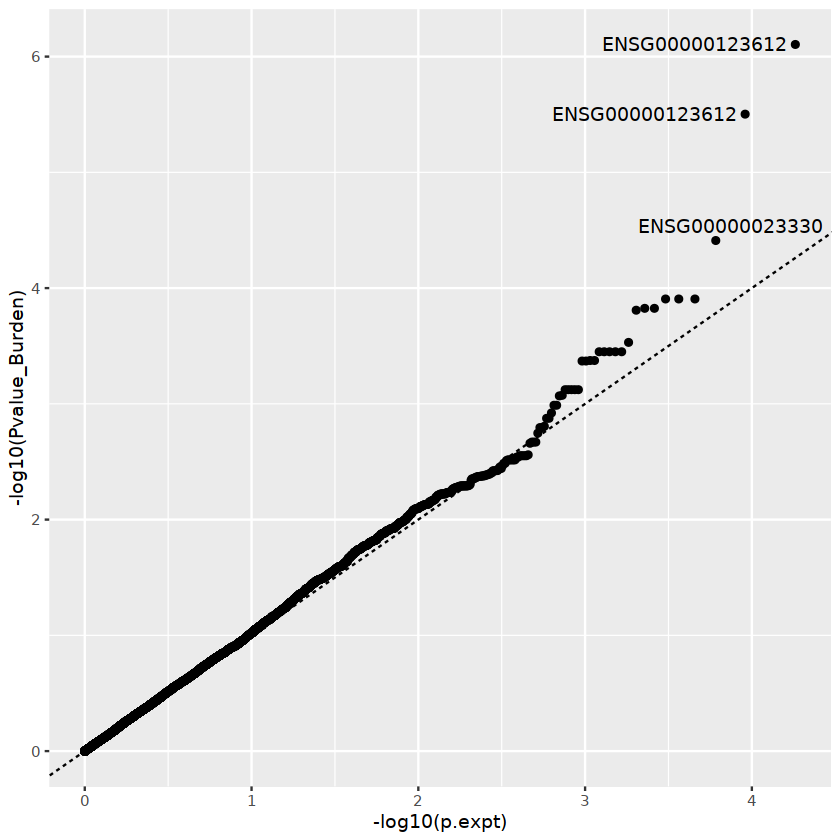

In [42]:
ggplot(s, aes(x=-log10(p.expt), y=-log10(Pvalue_Burden), label = label)) + 
    geom_point() +
    geom_abline(linetype = 'dashed') +
    geom_text_repel()

In [12]:
x1 <- (1:n)/100
x2 <- sort(runif(n))

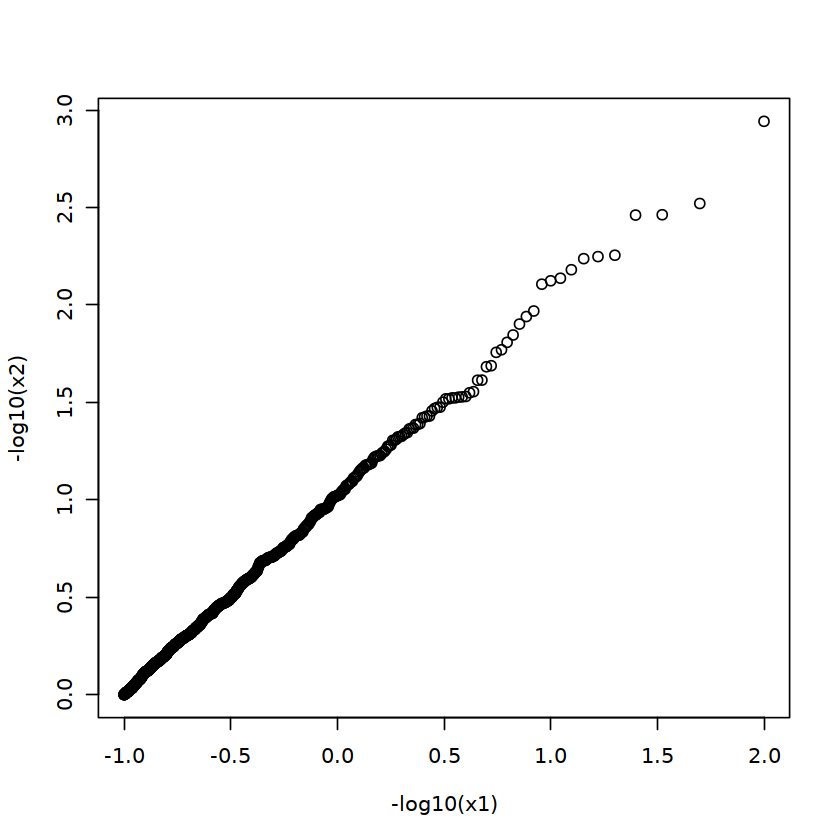

In [13]:
plot(-log10(x1),-log10(x2))

In [2]:
args <- list(
    spa_cts_dir = 'data/saige/output/cts/step2/'
    
)

In [3]:
spa_cts_files <- list.files(args$spa_cts_dir, pattern = ".txt.gz", full.names = TRUE)


In [4]:
spa_cts_files

[1] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense.txt.gz"  
 [2] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Albumin_residual_pLoF_damaging_missense.txt.gz"                   
 [3] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Alkaline_Phosphatase_residual_pLoF_damaging_missense.txt.gz"      
 [4] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Apolipoprotein_A_residual_pLoF_damaging_missense.txt.gz"          
 [5] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Apolipoprotein_B_residual_pLoF_damaging_missense.txt.gz"          
 [6] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Aspartate_aminotransferase_residual_pLoF_damaging_missense.txt.gz"
 [7] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_BMI_imp_pLoF_damaging_missense.txt.gz"                            
 [8] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_BMI_pLoF_damaging_missense.txt.gz"                                
 [9] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_C_reactive_Protein_residual_pLoF_damaging_missense.txt.gz"        
[10] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Calcium_residual_pLoF_damaging_missense.txt.gz"                   
[11] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Cholesterol_residual_pLoF_damaging_missense.txt.gz"               
[12] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Creatinine_Serum_residual_pLoF_damaging_missense.txt.gz"          
[13] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Creatinine_Urine_residual_pLoF_damaging_missense.txt.gz"          
[14] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Cystatin_C_Serum_residual_pLoF_damaging_missense.txt.gz"          
[15] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Direct_Bilirubin_residual_pLoF_damaging_missense.txt.gz"          
[16] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Gamma_glutamyltransferase_residual_pLoF_damaging_missense.txt.gz" 
[17] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Glucose_residual_pLoF_damaging_missense.txt.gz"                   
[18] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_HDL_Cholesterol_residual_pLoF_damaging_missense.txt.gz"           
[19] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_HbA1c_residual_pLoF_damaging_missense.txt.gz"                     
[20] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_IGF_1_residual_pLoF_damaging_missense.txt.gz"                     
[21] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Lipoprotein_A_residual_pLoF_damaging_missense.txt.gz"             
[22] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Phosphate_residual_pLoF_damaging_missense.txt.gz"                 
[23] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Potassium_Urine_residual_pLoF_damaging_missense.txt.gz"           
[24] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_SHBG_residual_pLoF_damaging_missense.txt.gz"                      
[25] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Sodium_Urine_residual_pLoF_damaging_missense.txt.gz"              
[26] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Testosterone_residual_pLoF_damaging_missense.txt.gz"              
[27] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Total_Bilirubin_residual_pLoF_damaging_missense.txt.gz"           
[28] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Total_Protein_residual_pLoF_damaging_missense.txt.gz"             
[29] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Triglyceride_residual_pLoF_damaging_missense.txt.gz"              
[30] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Urate_residual_pLoF_damaging_missense.txt.gz"                     
[31] "data/saige/output/cts/step2//ukb_eur_wes_200k_maf0to5e-2_Urea_residual_pLoF_damaging_missense.t

In [11]:
fread_with_basename <- function(f){
    d <- fread(f)
    file_sans_gz <- tools::file_path_sans_ext(basename(f))
    file_sans_txt <- tools::file_path_sans_ext(file_sans_gz)
    d$basename <- file_sans_txt
    return(d)
}

In [31]:

spa_cts <- do.call(rbind, lapply(spa_cts_files, fread_with_basename))

In [30]:
tabulate_marker_basename <- function(M){
    stopifnot(all(c("MarkerID",'basename') %in% colnames(M)))
    d <- as.data.frame(table(M$MarkerID, M$basename))
    colnames(d) <- c("MarkerID", "basename", "Freq")
    d <- d[d$Freq > 0,]
    d$Freq <- NULL
    return(d)
}


In [32]:
tabulate_marker_basename(spa_cts)

,MarkerID,basename
,<fct>,<fct>
1,ENSG00000001626,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
2,ENSG00000003989,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
3,ENSG00000004139,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
4,ENSG00000004700,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
5,ENSG00000004846,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
7,ENSG00000005381,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
8,ENSG00000005469,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
9,ENSG00000006071,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
10,ENSG00000006283,ukb_eur_wes_200k_maf0to5e-2_Alanine_aminotransferase_residual_pLoF_damaging_missense
